ΚΟΥΜΠΟΓΙΑΝΝΗ ΧΡΙΣΤΙΝΑ, Α.Μ.:140

# GRU RNN + DEEP REINFORCEMENT LEARNING


Πραγμτοποιείται πρόβλεψη 4 χαρακτηριστικών καιρού για το Νέο Δελχί (θερμοκρασία, υγρασία, άνεμος, πίεση) για την επόμενη μέρα, με βάση τα δεδομένα των προηγούμενων 60 ημερών.


#### 1. Φόρτωση & Κανονικοποίηση Δεδομένων

- train set and test set: `DailyDelhiClimateTrain.csv` και `DailyDelhiClimateTest.csv`.
- Μετατροπή της στήλης `date` σε `datetime`.
- Επιλογή 4 χαρακτηριστικών: `meantemp`, `humidity`, `wind_speed`, `meanpressure`.
- Εφαρμογή **MinMaxScaler** για κανονικοποίηση των τιμών κάθε χαρακτηριστικού στο διάστημα [0, 1].


#### 2. Δημιουργία Ακολουθιών

- Μετατροπή των δεδομένων σε ακολουθίες:
  - Είσοδος: ακολουθία 60 ημερών με 4 χαρακτηριστικά (60, 4)
  - Πρόβλεψη: τιμές 4 χαρακτηριστικών την επόμενη μέρα (4,)



#### 3. Αρχιτεκτονική Πράκτορα (NeuralAgent)

Κάθε νευρωνικό δίκτυο που έχει ένας agent περιλαμβάνει:

 **Είσοδος**: μία μόνο τιμή (1 feature)
 **Δίκτυο**:
- Πλήρως συνδεδεμένο στρώμα:  
  `W1 ∈ ℝ^(hidden_dim × 1)` → ενεργοποίηση `tanh`
- Πλήρως συνδεδεμένο στρώμα εξόδου:
  `W2 ∈ ℝ^(1 × hidden_dim)` → ενεργοποίηση `tanh`
- Έξοδος: το **mean** μιας κανονικής κατανομής `N(mean, std²)`
- Δράση (action): δειγματοληψία από την `N(mean, std)` και περιορίζεται σε μικρό εύρος
- Ενημέρωση βαρών: με αλγόριθμο **REINFORCE** (χωρίς backpropagation μέσω GRU)

 -- Σκοπός Πράκτορα: να μάθει να τροποποιεί ελαφρώς την είσοδο για να ελαχιστοποιηθεί το σφάλμα πρόβλεψης για το αντίστοιχο χαρακτηριστικό



#### 4. Αρχιτεκτονική GRU

 **Δομή**:
- Είσοδος ανά timestep: `x_t ∈ ℝ^4` (1 μέρα, 4 χαρακτηριστικά)
- Κρυφή κατάσταση: `h_t ∈ ℝ^hidden_size` (264 διαστάσεις)

 **GRU Cell Υπολογισμοί**:
1. **z (update gate)** = sigmoid(W_z @ x_t + U_z @ h_prev + b_z)  
2. **r (reset gate)** = sigmoid(W_r @ x_t + U_r @ h_prev + b_r)  
3. **h_TILDE (candidate state)** = tanh(W_h @ x_t + U_h @ (r * h_prev) + b_h)  
4. **h_t** = (1 - z) * h_TILDE + z * h_prev

Μετά την τελευταία μέρα (60 timesteps), λαμβάνει το τελικό `h_T`.

**Προβλεπτική στρώση (Linear Layer)**:
- `y_pred = tanh(W_out @ h_T + b_out)`: δίνει πρόβλεψη για τα 4 χαρακτηριστικά

#### 5. Εκπαίδευση
 Για κάθε εποχή:

- Για κάθε δείγμα:
  1. Οι **πράκτορες** εφαρμόζουν δράσεις για να τροποποιήσουν τα χαρακτηριστικά εισόδου.
  2. Η **GRU** υπολογίζει την πρόβλεψη (`y_pred`).
  3. Υπολογίζεται το **σφάλμα MSE**.
  4. Γίνεται **ενημέρωση των βαρών του `W_out`** με backpropagation.
  5. Οι **πράκτορες παίρνουν ανταμοιβές** (αρνητικό απόλυτο σφάλμα) και προσαρμόζουν τα βάρη τους με REINFORCE.



#### 6. Αποτελέσματα

- Υπολογίζεται το **RMSE** ανά χαρακτηριστικό, μετατρέποντας τις κανονικοποιημένες τιμές στην αρχική κλίμακα.
- Χρησιμοποιείται `inverse_transform` για την αποκατάσταση των τιμών.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Load and preprocess data 
data_path = "C:/Users/hp-5c/Desktop/deepLearning/archive/"
trainset = pd.read_csv(data_path + "DailyDelhiClimateTrain.csv")
testset = pd.read_csv(data_path + "DailyDelhiClimateTest.csv")
#Each row corresponds to a day and includes values for 4 features

#Converts the date to datetime format and sets it as index to allow time-series operations
for df in [trainset, testset]:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure'] #4 features

# Normalize each feature independently 0-1 using MinMaxScalar
scalers = {}
train_scaled = pd.DataFrame(index=trainset.index)
test_scaled = pd.DataFrame(index=testset.index)

for f in features:
    scaler = MinMaxScaler()
    train_scaled[f] = scaler.fit_transform(trainset[[f]])
    test_scaled[f] = scaler.transform(testset[[f]])
    scalers[f] = scaler

#2. Create sequences 
#Each input seq X[i] is shape (60, 4) - 60 days before / 4 features per day- and each target y[i]: (4,) is the value of the 4 features on the next day 61
def create_sequences_multi(data, seq_len=60):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data.iloc[i:i+seq_len].values)
        y.append(data.iloc[i+seq_len].values)
    return np.array(X), np.array(y)

seq_len = 60
X_train, y_train = create_sequences_multi(train_scaled, seq_len)
X_val, y_val = create_sequences_multi(test_scaled, seq_len)

#3. NeuralAgent with feature-wise action clipping and reward shaping
class NeuralAgent:
    def __init__(self, input_dim, f_index, hidden_dim=16, lr=0.001, std=0.05):
        self.lr = lr
        self.std = std
        self.feature_idx = f_index
        self.W1 = np.random.randn(hidden_dim, input_dim) * 0.1 # shape: (hidden_dim × 1)
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = np.random.randn(1, hidden_dim) * 0.1 # shape: (1 × hidden_dim)
        self.b2 = np.zeros((1, 1))

    def forward(self, x):  #1 hidden layer with tanh
        x = x.reshape(-1, 1)
        z1 = np.tanh(self.W1 @ x + self.b1)
        mean = np.tanh(self.W2 @ z1 + self.b2).item()
        return mean, z1, x
    
    
    def act(self, x):  #Samples an action for the feature at each time step
        mean, self.z1, self.x = self.forward(x) #Είσοδος: μία τιμή (feature value)
        action = np.random.normal(loc=mean, scale=self.std) #Κατανομή και δειγματοληψία
        #Περιορισμός δράσης σε μικρό εύρος (clipping)
        f_range = scalers[features[self.feature_idx]].data_max_[0] - scalers[features[self.feature_idx]].data_min_[0]
        clip_amt = (0.05 / f_range)
        action = np.clip(action, -clip_amt, clip_amt)
        self.last_action = action
        self.last_mean = mean
        return action

    def update(self, reward): # Applies reinforce update to the weights using the reward based on prediction accuracy
        #Ενημέρωση βαρών (REINFORCE)
        dmean = (self.last_action - self.last_mean) / (self.std ** 2)
        dz2 = reward * dmean * (1 - self.last_mean ** 2)
        dW2 = dz2 * self.z1.T
        db2 = dz2

        dz1 = (self.W2.T * dz2) * (1 - self.z1 ** 2)
        dW1 = dz1 @ self.x.T
        db1 = dz1

        self.W2 += self.lr * dW2 
        self.b2 += self.lr * db2
        self.W1 += self.lr * dW1
        self.b1 += self.lr * db1

#4. Initialize agents
input_size = len(features)
agents = [NeuralAgent(1, i) for i in range(input_size)] #init 4 agents, 1/feature
#Each agent modifies one scalar input at each time step in the sequence

#5. GRU Model Setup
hidden_size = 264
output_size = input_size
np.random.seed(42)

#Update gate (z), Reset gate (r), candidate hidden state (h)
W_z, U_z, b_z = np.random.randn(hidden_size, input_size) * 0.1, np.random.randn(hidden_size, hidden_size) * 0.1, np.zeros((hidden_size, 1)) #update gate
W_r, U_r, b_r = np.random.randn(hidden_size, input_size) * 0.1, np.random.randn(hidden_size, hidden_size) * 0.1, np.zeros((hidden_size, 1)) # reset gate
W_h, U_h, b_h = np.random.randn(hidden_size, input_size) * 0.1, np.random.randn(hidden_size, hidden_size) * 0.1, np.zeros((hidden_size, 1)) #candidate state
W_out = np.random.randn(output_size, hidden_size) * 0.01 #Final linear layer to convert last hidden state to 4 predicted values -- πρόβλεψη


b_out = np.zeros((output_size, 1))

#6. GRU Forward: one-layer GRU cell across a seq
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)

def gru_forward(x_seq):   #single-layer GRU implementation
    #For each timestep t:Compute update and reset gates,candidate hidden state, new hidden state.


    h = np.zeros((hidden_size, 1))
    for t in range(seq_len):
        x_t = x_seq[t].reshape(-1, 1)
        z = sigmoid(W_z @ x_t + U_z @ h + b_z) #update gate
        r = sigmoid(W_r @ x_t + U_r @ h + b_r) # reset gate
        h_tilde = tanh(W_h @ x_t + U_h @ (r * h) + b_h) #candidate state
        h = (1 - z) * h_tilde + z * h  #τελικό h_t
    return tanh(W_out @ h + b_out).flatten() #y_pred = tanh(W_out @ h_T + b_out) - προβλεπτική στρώση

#7. Modify Input with Agent Actions
#For each feature f at each timestep t, the agent:Computes an actionusing neural network, and adds it to the input value (clipped to [0, 1]).
def modify_input_with_agents(x_seq, agents):
    x_mod = x_seq.copy()
    for t in range(x_mod.shape[0]):
        for f in range(x_mod.shape[1]):
            action = agents[f].act(np.array([x_mod[t, f]]))
            x_mod[t, f] += action
            x_mod[t, f] = np.clip(x_mod[t, f], 0, 1)
    return x_mod

#8. Training Loop
def train_model(X_train, y_train, X_val, y_val, lr=0.001, epochs=70):
    global W_out, b_out
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_seq = X_train[i]
            y_true = y_train[i]
            x_mod = modify_input_with_agents(x_seq, agents)
            y_pred = gru_forward(x_mod)

            loss = np.mean((y_pred - y_true) ** 2)
            dy = 2 * (y_pred - y_true).reshape(-1, 1) / output_size

            h = np.zeros((hidden_size, 1))
            for t in range(seq_len):
                x_t = x_mod[t].reshape(-1, 1)
                z = sigmoid(W_z @ x_t + U_z @ h + b_z)
                r = sigmoid(W_r @ x_t + U_r @ h + b_r)
                h_tilde = tanh(W_h @ x_t + U_h @ (r * h) + b_h)
                h = (1 - z) * h_tilde + z * h

            dW_out = dy @ h.T
            db_out = dy
            W_out -= lr * dW_out
            b_out -= lr * db_out

            for f, agent in enumerate(agents):
                f_range = scalers[features[f]].data_max_[0] - scalers[features[f]].data_min_[0]
                reward = -abs(y_pred[f] - y_true[f]) / (f_range + 1e-8)
                agent.update(reward)

        val_preds = np.array([gru_forward(modify_input_with_agents(x, agents)) for x in X_val])
        val_loss = np.mean((val_preds - y_val) ** 2)
        print(f"Epoch {epoch+1} | Val Loss: {val_loss:.6f}")
    return val_preds

val_preds = train_model(X_train, y_train, X_val, y_val)

# 9. Evaluation
from sklearn.metrics import mean_squared_error

def inverse_feature(col, norm_vals):
    scaler = scalers[col]
    return scaler.inverse_transform(norm_vals.reshape(-1, 1)).flatten()

def evaluate_model(y_val, val_preds):
    print("\nValidation RMSE per feature:")
    for i, col in enumerate(features):
        y_inv = inverse_feature(col, y_val[:, i])
        p_inv = inverse_feature(col, val_preds[:, i])
        rmse = np.sqrt(mean_squared_error(y_inv, p_inv))
        print(f"{col}: RMSE = {rmse:.3f}")

evaluate_model(y_val, val_preds)


Epoch 1 | Val Loss: 0.018433
Epoch 2 | Val Loss: 0.015851
Epoch 3 | Val Loss: 0.013679
Epoch 4 | Val Loss: 0.012024
Epoch 5 | Val Loss: 0.010768
Epoch 6 | Val Loss: 0.009811
Epoch 7 | Val Loss: 0.009079
Epoch 8 | Val Loss: 0.008516
Epoch 9 | Val Loss: 0.008080
Epoch 10 | Val Loss: 0.007741
Epoch 11 | Val Loss: 0.007475
Epoch 12 | Val Loss: 0.007264
Epoch 13 | Val Loss: 0.007096
Epoch 14 | Val Loss: 0.006960
Epoch 15 | Val Loss: 0.006849
Epoch 16 | Val Loss: 0.006757
Epoch 17 | Val Loss: 0.006680
Epoch 18 | Val Loss: 0.006614
Epoch 19 | Val Loss: 0.006557
Epoch 20 | Val Loss: 0.006507
Epoch 21 | Val Loss: 0.006462
Epoch 22 | Val Loss: 0.006422
Epoch 23 | Val Loss: 0.006385
Epoch 24 | Val Loss: 0.006351
Epoch 25 | Val Loss: 0.006319
Epoch 26 | Val Loss: 0.006289
Epoch 27 | Val Loss: 0.006260
Epoch 28 | Val Loss: 0.006233
Epoch 29 | Val Loss: 0.006206
Epoch 30 | Val Loss: 0.006180
Epoch 31 | Val Loss: 0.006156
Epoch 32 | Val Loss: 0.006131
Epoch 33 | Val Loss: 0.006108
Epoch 34 | Val Loss

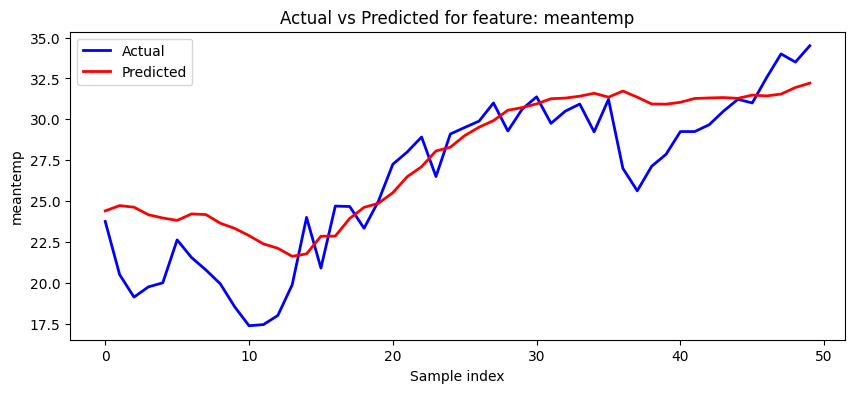

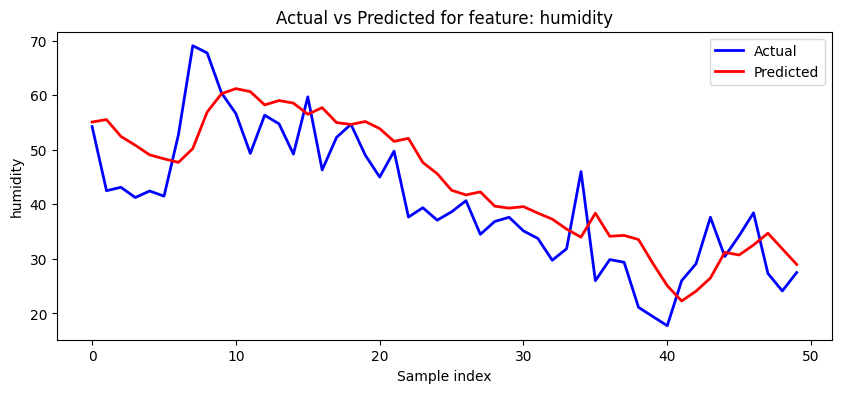

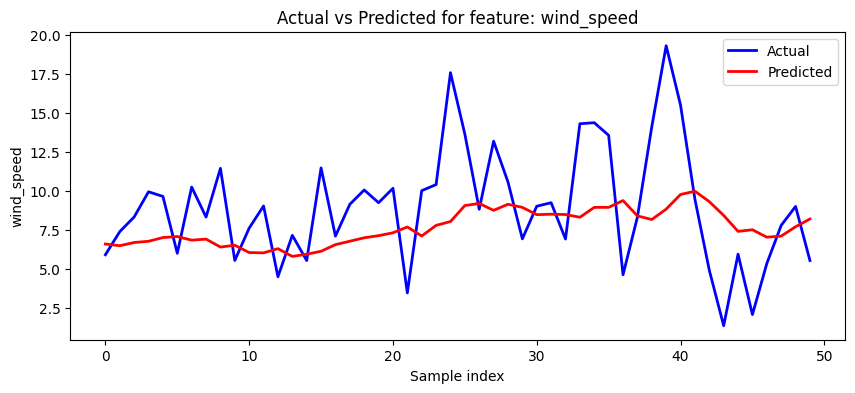

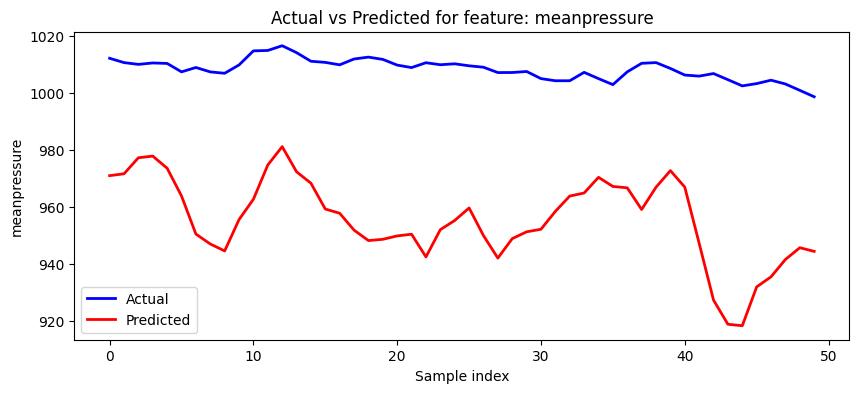

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions_lines_per_feature(y_val, val_preds, features, scalers, sample_indices=None):
    
    if sample_indices is None:
        sample_indices = range(len(y_val))

    for i, feature in enumerate(features):
        plt.figure(figsize=(10, 4))

        # Inverse transform all samples for this feature at once for efficiency
        y_true_inv = scalers[feature].inverse_transform(y_val[sample_indices, i].reshape(-1, 1)).flatten()
        y_pred_inv = scalers[feature].inverse_transform(val_preds[sample_indices, i].reshape(-1, 1)).flatten()

        plt.plot(sample_indices, y_true_inv, label="Actual", color="blue", linewidth=2)
        plt.plot(sample_indices, y_pred_inv, label="Predicted", color="red",  linewidth=2)

        plt.title(f"Actual vs Predicted for feature: {feature}")
        plt.xlabel("Sample index")
        plt.ylabel(feature)
        plt.legend()
        plt.show()

# Example usage:
plot_predictions_lines_per_feature(y_val, val_preds, features, scalers, sample_indices=range(50))
